In [19]:
!pip install pandas matplotlib seaborn openpyxl

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df = pd.read_excel("cleaned_books.xlsx")

In [50]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Number"] = df["Rating"].map(rating_map)

In [51]:
sns.set_style("whitegrid")

sns.set_palette("mako")

plt.rcParams["figure.figsize"] = (10,6)

plt.rcParams["font.size"] = 12

plt.rcParams["axes.titlesize"] = 18

plt.rcParams["axes.labelsize"] = 13

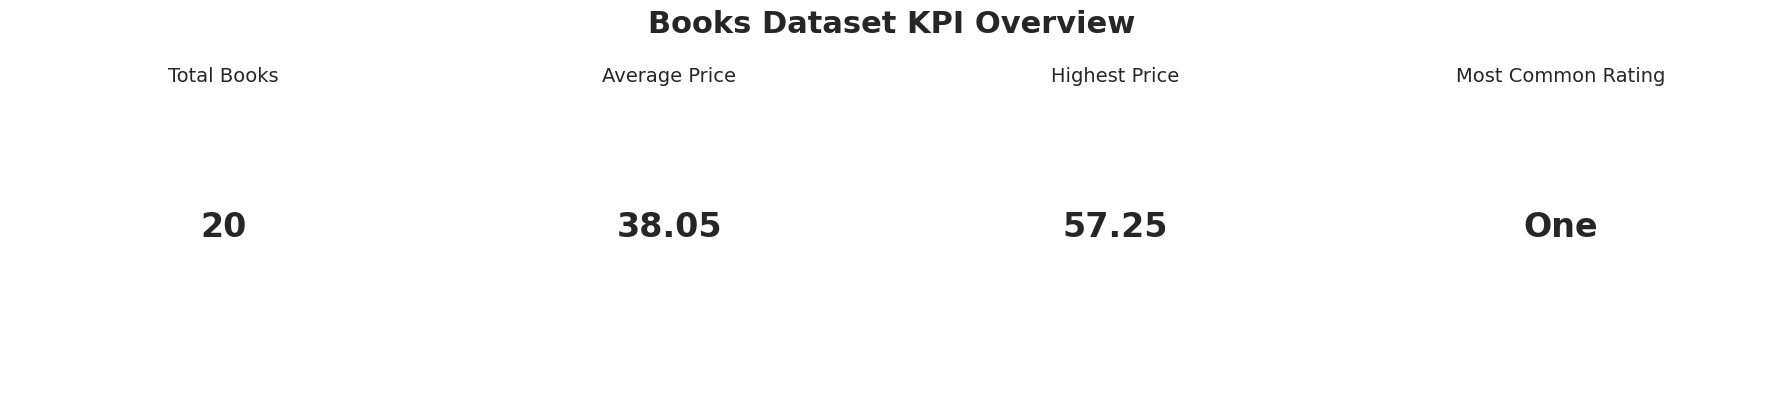

In [59]:
# KPI DASHBOARD

fig, axes = plt.subplots(1, 4, figsize=(18,4))

fig.suptitle(
    "Books Dataset KPI Overview",
    fontsize=22,
    fontweight="bold"
)

kpis = [
    ("Total Books", len(df)),
    ("Average Price", round(df["Price"].mean(), 2)),
    ("Highest Price", round(df["Price"].max(), 2)),
    ("Most Common Rating", df["Rating"].mode()[0])
]

for ax, (title, value) in zip(axes, kpis):

    ax.text(
        0.5,
        0.5,
        str(value),
        fontsize=24,
        fontweight='bold',
        ha='center'
    )

    ax.set_title(title, fontsize=14)

    ax.set_xticks([])

    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()

plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

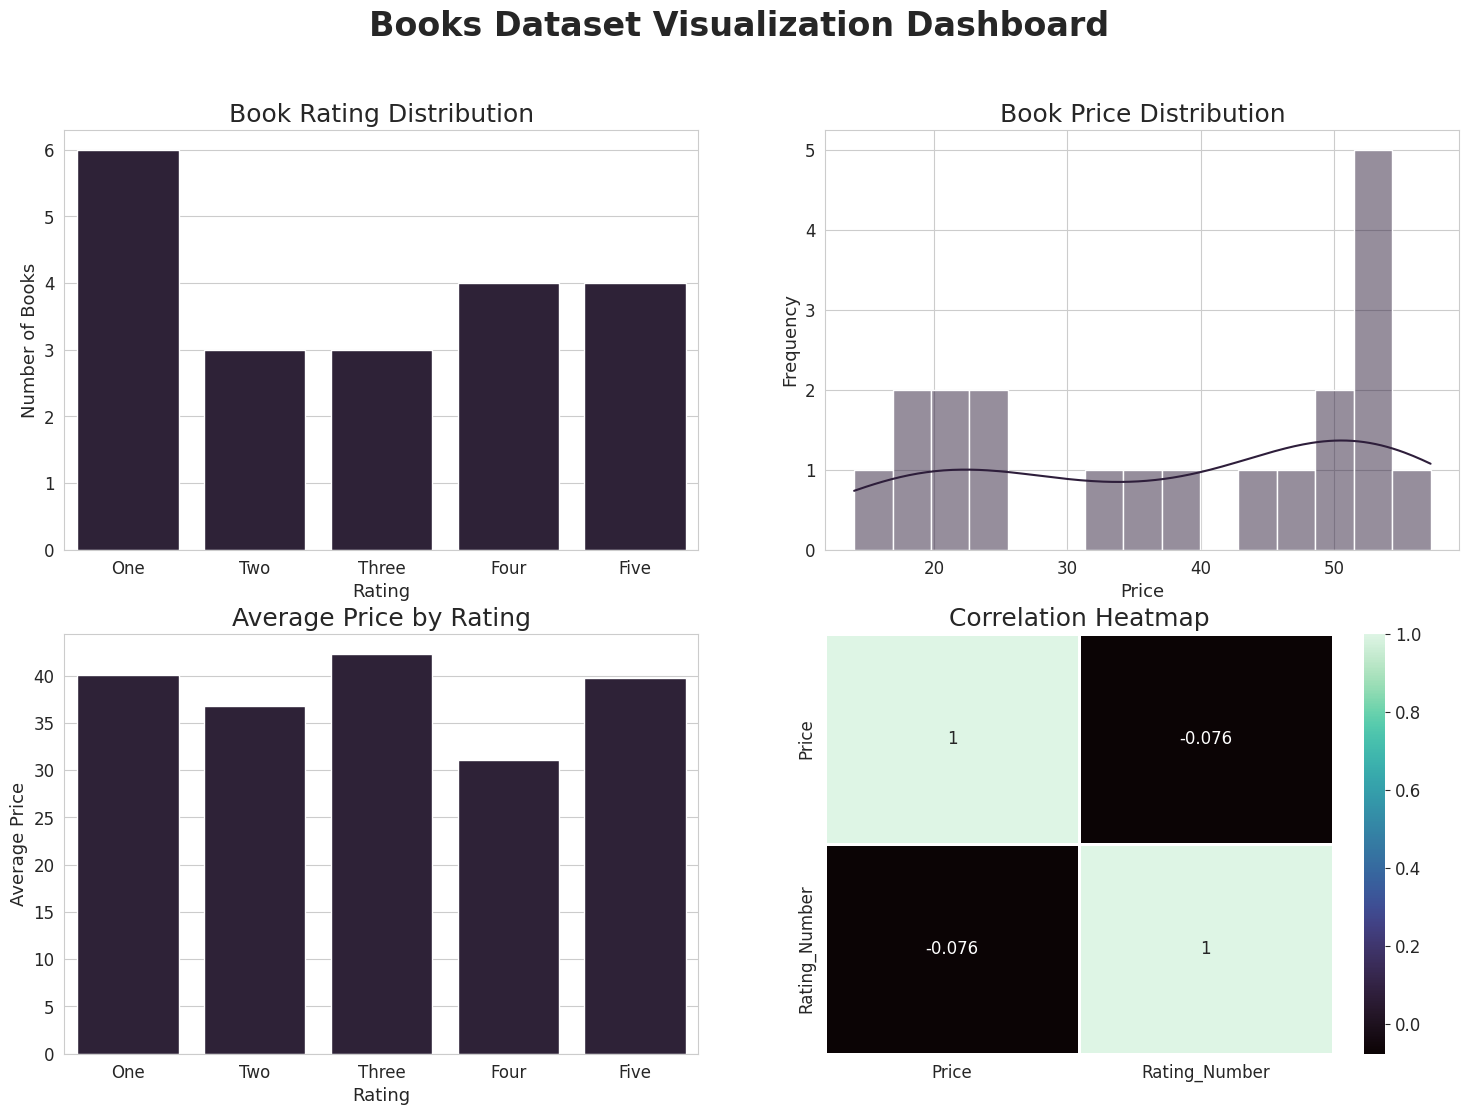

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

fig.suptitle(
    "Books Dataset Visualization Dashboard",
    fontsize=24,
    fontweight="bold"
)
sns.countplot(
    x="Rating",
    data=df,
    order=["One", "Two", "Three", "Four", "Five"],
    ax=axes[0,0]
)

axes[0,0].set_title("Book Rating Distribution")

axes[0,0].set_xlabel("Rating")

axes[0,0].set_ylabel("Number of Books")



sns.histplot(
    df["Price"],
    bins=15,
    kde=True,
    ax=axes[0,1]
)

axes[0,1].set_title("Book Price Distribution")

axes[0,1].set_xlabel("Price")

axes[0,1].set_ylabel("Frequency")


avg_price = df.groupby("Rating")["Price"].mean().reindex(
    ["One", "Two", "Three", "Four", "Five"]
)

sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    ax=axes[1,0]
)

axes[1,0].set_title("Average Price by Rating")

axes[1,0].set_xlabel("Rating")

axes[1,0].set_ylabel("Average Price")


correlation = df[["Price", "Rating_Number"]].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="mako",
    linewidths=2,
    ax=axes[1,1]
)

axes[1,1].set_title("Correlation Heatmap")

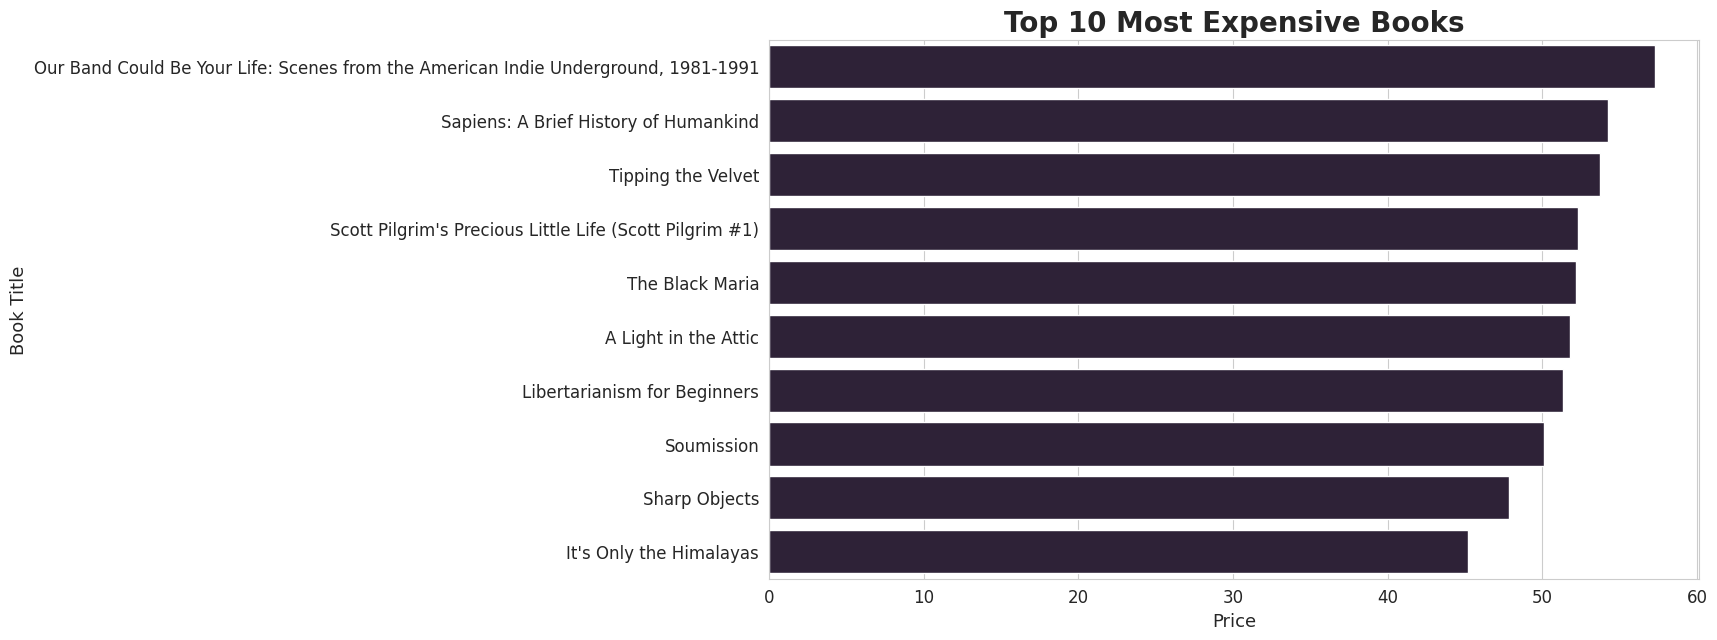

In [56]:
top_books = df.sort_values(by="Price", ascending=False).head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x="Price",
    y="Book Title",
    data=top_books
)

plt.title(
    "Top 10 Most Expensive Books",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Price")

plt.ylabel("Book Title")

plt.show()

In [58]:
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dashboard.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 1000x600 with 0 Axes>

In [60]:
from google.colab import files

files.download("dashboard.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>